# Smoothing: LOESS, Splines, and Kernel Methods

## Overview
Smoothers estimate the trend in a scatterplot without assuming a parametric functional form. They are essential for exploratory analysis and for detecting non-linear relationships before choosing a model.

| Smoother | Key parameter | R function | Notes |
|---|---|---|---|
| LOESS/LOWESS | span (bandwidth) | `loess()`, `geom_smooth()` | Local polynomial; robust option available |
| Regression splines | knots, degree | `splines::bs()`, `ns()` | Fixed knot locations; used inside `lm()` |
| Smoothing splines | df or λ | `smooth.spline()` | GCV-selected smoothness |
| Kernel | bandwidth h | `ksmooth()` | Simple; less used in ecology |

**Relationship to GAMs:** `mgcv::gam()` uses penalised regression splines — GAMs are the principled modelling extension of smoothers. Quinn & Keough (2002) ch. 5.

---

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Temperature time series: n = 200 observations


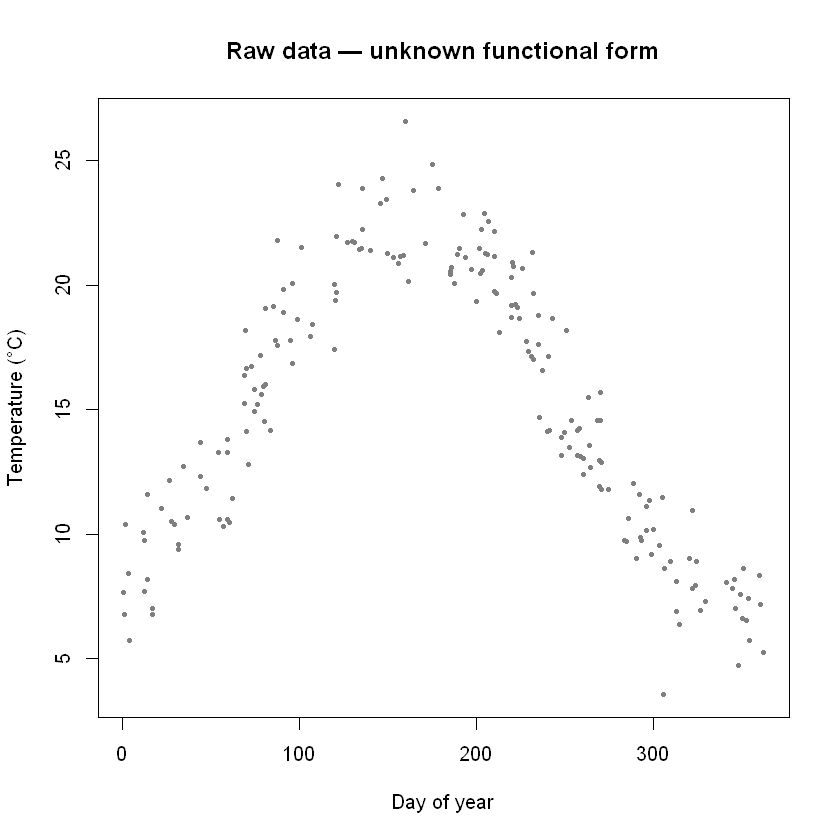

In [1]:
library(tidyverse); library(splines)
set.seed(17)
# Intertidal temperature time series with non-linear seasonal pattern
n <- 200
days <- sort(runif(n, 1, 365))
temp <- 15 + 8*sin(2*pi*days/365 - 1.2) + rnorm(n, 0, 1.5)
dat  <- data.frame(day=days, temp=temp)
cat("Temperature time series: n =", n, "observations\n")
plot(dat$day, dat$temp, pch=16, cex=0.5, col="grey50",
     xlab="Day of year", ylab="Temperature (°C)",
     main="Raw data — unknown functional form")

---
## LOESS: local polynomial smoothing

Span too small → overfit; too large → underfit (bias-variance tradeoff)
span = 0.3–0.5 is a reasonable default for ecological data


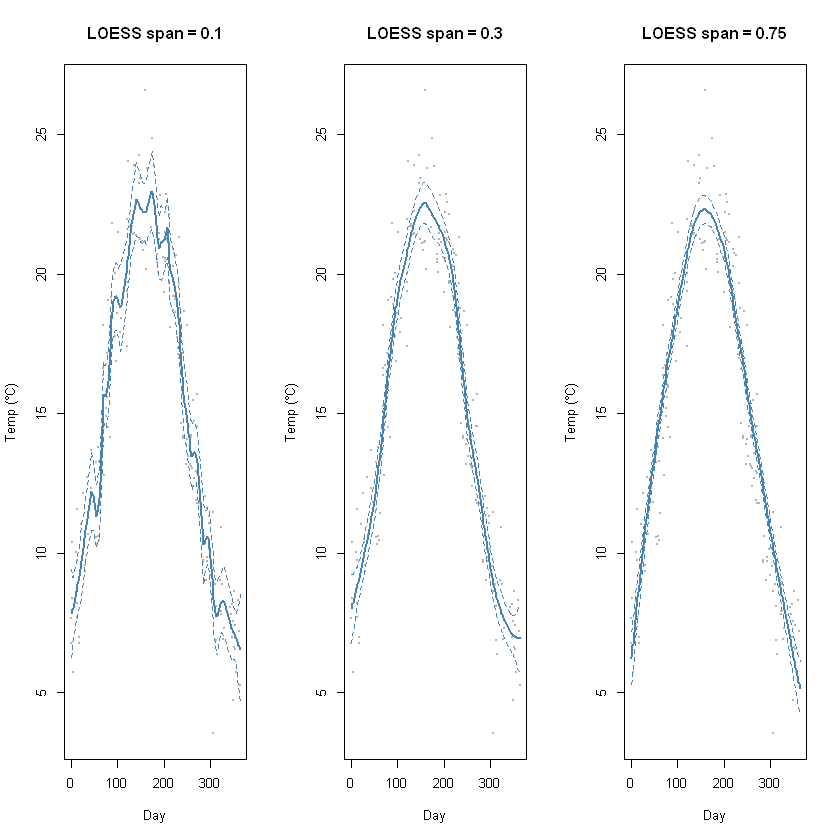

In [2]:
# LOESS with different span values (bandwidth controls smoothness)
par(mfrow=c(1,3))
for (sp in c(0.1, 0.3, 0.75)) {
  lo <- loess(temp ~ day, data=dat, span=sp)
  pred <- predict(lo, se=TRUE)
  plot(dat$day, dat$temp, pch=16, cex=0.4, col="grey70",
       main=paste("LOESS span =", sp),
       xlab="Day", ylab="Temp (°C)")
  lines(dat$day, pred$fit, col="steelblue", lwd=2)
  lines(dat$day, pred$fit + 1.96*pred$se.fit, col="steelblue", lty=2)
  lines(dat$day, pred$fit - 1.96*pred$se.fit, col="steelblue", lty=2)
}
par(mfrow=c(1,1))
cat("Span too small → overfit; too large → underfit (bias-variance tradeoff)\n")
cat("span = 0.3–0.5 is a reasonable default for ecological data\n")

---
## Regression splines and smoothing splines

Natural spline model (df=6) R²: 0.914 
Smoothing spline equivalent df: 9.4 


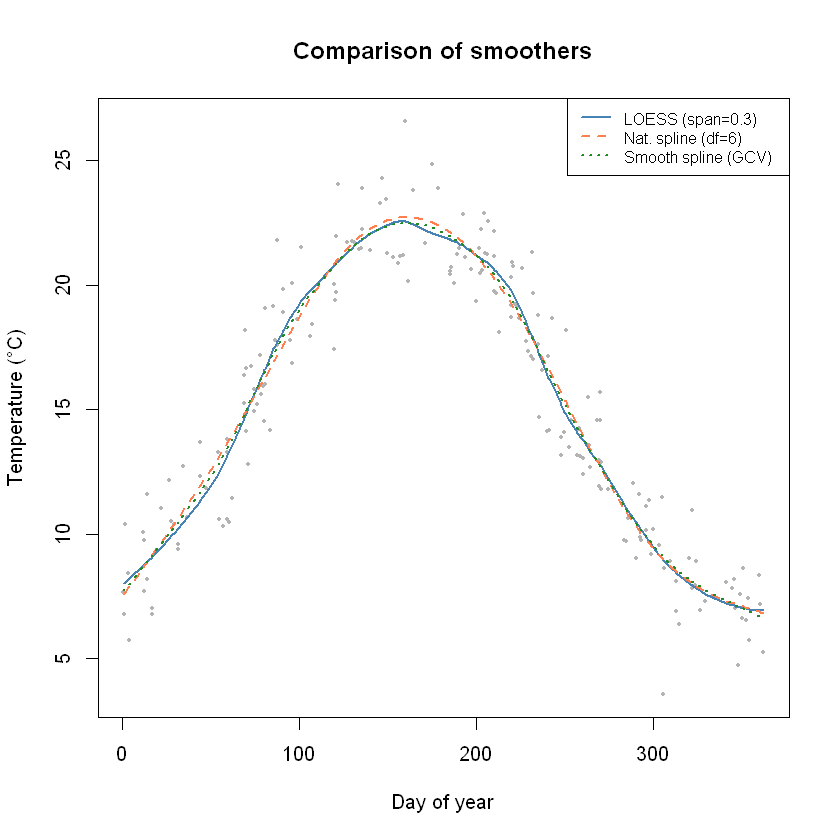

In [3]:
# Natural cubic splines inside lm() — interpretable coefficients
m_ns <- lm(temp ~ ns(day, df=6), data=dat)   # df controls flexibility
cat("Natural spline model (df=6) R²:", round(summary(m_ns)$r.squared, 3), "\n")

# Smoothing spline — GCV selects smoothness automatically
ss <- smooth.spline(dat$day, dat$temp, cv=FALSE)   # cv=FALSE → GCV
cat("Smoothing spline equivalent df:", round(ss$df, 2), "\n")

# Plot all three smoothers together
plot(dat$day, dat$temp, pch=16, cex=0.4, col="grey70",
     xlab="Day of year", ylab="Temperature (°C)",
     main="Comparison of smoothers")
lo_pred <- predict(loess(temp~day, data=dat, span=0.3))
lines(dat$day, lo_pred, col="steelblue", lwd=2)
lines(dat$day, predict(m_ns), col="coral", lwd=2, lty=2)
lines(ss, col="forestgreen", lwd=2, lty=3)
legend("topright",
       legend=c("LOESS (span=0.3)","Nat. spline (df=6)","Smooth spline (GCV)"),
       col=c("steelblue","coral","forestgreen"), lwd=2, lty=1:3, cex=0.8)

`geom_smooth()` using formula = 'y ~ x'


geom_smooth defaults:
  n < 1000: method='loess'
  n ≥ 1000: method='gam' (mgcv::gam with s(x, bs='cs'))

For inferential modelling, use mgcv::gam() directly (see 04_gams folder)


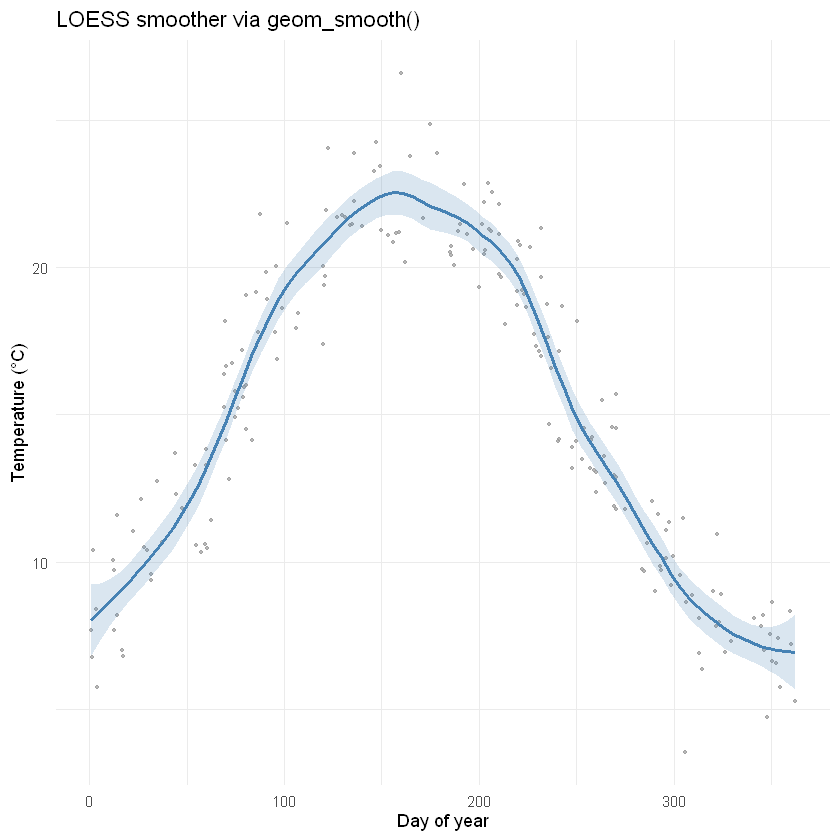

In [4]:
# ggplot2 geom_smooth for exploratory plots
ggplot(dat, aes(day, temp)) +
  geom_point(colour="grey60", size=0.8, alpha=0.7) +
  geom_smooth(method="loess", span=0.3, colour="steelblue",
              fill="steelblue", alpha=0.2) +
  labs(title="LOESS smoother via geom_smooth()",
       x="Day of year", y="Temperature (°C)") +
  theme_minimal()

cat("geom_smooth defaults:\n")
cat("  n < 1000: method='loess'\n")
cat("  n ≥ 1000: method='gam' (mgcv::gam with s(x, bs='cs'))\n")
cat("\nFor inferential modelling, use mgcv::gam() directly (see 04_gams folder)\n")

---
## Common Pitfalls

**1. Over-interpreting LOESS features as real biological patterns**
LOESS is an exploratory tool. Small wiggles in a LOESS curve may reflect noise rather than real non-linearity, especially with small span values. Always consider the confidence band width before interpreting local peaks and troughs as biologically meaningful.

**2. Using smoothers in place of a model**
Smoothers describe patterns but don't provide parameter estimates, p-values, or predictions with uncertainty for new data. For inference, use `mgcv::gam()` (penalised splines) or regression splines within `lm()`. LOESS cannot be extrapolated beyond the data range.

**3. Choosing span/df by eye rather than by cross-validation**
Span/df selection is equivalent to model complexity selection. For inference rather than pure description, use GCV (as `smooth.spline()` does) or `mgcv::gam()` which selects penalty via GCV/REML automatically.

**4. Applying geom_smooth for hypothesis testing**
`geom_smooth()` is for exploration. Its confidence band is a pointwise band, not a simultaneous band across the whole curve. Do not report it as a formal test of non-linearity.

**5. Using polynomial regression as a substitute for splines**
Global high-degree polynomials (degree ≥ 4) behave erratically at the boundaries (Runge's phenomenon) and over-fit interior patterns. Natural splines or LOESS are more stable for capturing smooth non-linear trends.

**6. Not recognising that LOESS does not handle missing data or irregular spacing well**
LOESS uses local neighbourhoods. Widely spaced data or large gaps can produce misleading smooths in sparse regions. Check for data gaps before trusting the smooth in those regions.


---
*r_methods_library - Samantha McGarrigle*